### Credit Card Fraud Detection

Dataset from Kaggle : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
path = 'data/creditcard.csv'
df = pd.read_csv(path) #importing csv file
colors = ["#ff0000", "#0000ff"] #color palette for graphs


### EDA

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

The dataset consist of 31 columns and 284807 records.

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [7]:
no_fraud = df['Class'].value_counts()[0]
fraud = df["Class"].value_counts()[1]
print("No Fraud:", no_fraud)
print("Fraud:", fraud)

percentage_of_no_fraud = round(no_fraud/len(df) * 100, 2)
percentage_of_fraud = round(fraud/len(df) * 100, 2)
print(percentage_of_no_fraud, "% of No Fraund in dataset.")
print(percentage_of_fraud, "% of Fraud in dataset.")

No Fraud: 284315
Fraud: 492
99.83 % of No Fraund in dataset.
0.17 % of Fraud in dataset.


The dataset is imbalace. The model will overfit and assume that most transaction are NOT FRAUD.

Text(0.5, 1.0, 'Class Distribution \n (0: No Fraud || 1: Fraud)')

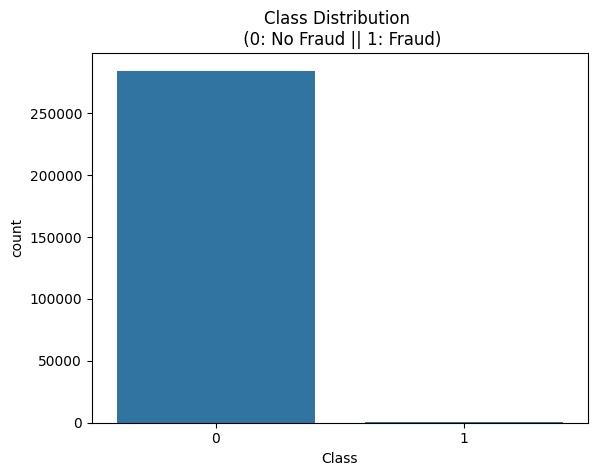

In [8]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution \n (0: No Fraud || 1: Fraud)")


We can see how skew the data is.

### Feature Engineering

Robust Scaler to scale remaning columns "Amount" & "Time"

In [9]:
#Scaling Remaining Columns : Time and Amount
from sklearn.preprocessing import RobustScaler

rob_scalar = RobustScaler() # Robust Scalar is less prone to outliers


scaled_df = df.copy(deep=True)
scaled_df['scaled_amount'] = rob_scalar.fit_transform(scaled_df['Amount'].values.reshape(-1,1))
scaled_df['scaled_time'] = rob_scalar.fit_transform(scaled_df['Time'].values.reshape(-1,1))



In [10]:
scaled_df.drop(['Amount', 'Time'], axis=1, inplace=True) 

In [11]:
scaled_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


#### Undersampling : Creating a dataframe with 50/50 ratio of fraud and non-fraud transaction.

Undersampling a dataset to have 50/50 Fraud/No Fraud Data

In [12]:
#Shuffing the data
scaled_df = scaled_df.sample(frac=1)

# amount of fraud classes 492 rows
fraud_df = scaled_df[df['Class'] == 1]
non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only

normal_distributed_pdf = pd.concat([fraud_df, non_fraud_df])

#shuffle dataframe rows again
new_df = normal_distributed_pdf.sample(frac=1, random_state=42)
new_df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18584\725605322.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fraud_df = scaled_df[df['Class'] == 1]
C:\Users\DELL\AppData\Local\Temp\ipykernel_18584\725605322.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
128121,-0.577230,1.172058,1.366728,-0.195313,0.304772,-0.762738,0.974543,-0.019375,-0.960417,-0.174834,...,-0.947751,-0.025060,0.295141,-0.198305,-0.054280,0.278054,0.156474,0,-0.268427,-0.071488
119781,-2.866364,2.346949,-4.053307,3.983359,-3.463186,-1.280953,-4.474764,1.216655,-2.309829,-5.515507,...,0.475840,0.404480,0.282030,-0.506901,-0.371741,0.615257,0.803163,1,1.432684,-0.107038
248422,-2.035099,-0.794551,0.054326,1.736195,1.633916,-0.783535,-0.933880,0.736183,-0.759555,-0.816111,...,0.068149,-0.455172,0.656761,0.438661,1.146459,-0.032206,-0.287649,0,-0.209739,0.813520
10630,-5.187878,6.967709,-13.510931,8.617895,-11.214422,0.672248,-9.462533,5.328704,-4.897006,-11.786812,...,0.760190,0.716806,-0.646743,-1.617043,0.172347,0.626647,-0.169726,1,10.401174,-0.785418
42769,-10.281784,6.302385,-13.271718,8.925115,-9.975578,-2.832513,-12.703253,6.706846,-7.078424,-12.805683,...,0.366933,0.042805,0.478279,0.157771,0.329901,0.163504,-0.485552,1,1.345630,-0.510521


In [13]:
new_df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,-2.417602,1.751722,-3.506510,2.320291,-1.560921,-0.718679,-2.784284,0.318147,-1.231657,-2.850957,...,0.002478,-0.036997,-0.037019,0.022838,0.034610,0.072069,0.037148,0.500000,1.214813,0.038256
std,5.593663,3.951132,6.229695,3.190392,4.220009,1.759984,5.855758,4.854230,2.342750,4.527915,...,1.170143,1.222770,0.569567,0.662355,0.483814,1.034252,0.491370,0.500254,3.963699,0.561979
min,-30.552380,-38.694338,-31.103685,-3.725738,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,-24.588262,...,-8.887017,-19.254328,-2.343194,-4.781606,-1.302357,-7.418878,-4.077946,0.000000,-0.307413,-0.990214
25%,-2.918600,-0.148287,-5.129049,-0.021095,-1.813966,-1.560262,-3.078361,-0.218661,-2.270235,-4.572043,...,-0.546999,-0.242201,-0.385836,-0.310068,-0.289463,-0.069158,-0.057471,0.000000,-0.289387,-0.453083
50%,-0.803009,0.962931,-1.380620,1.364654,-0.376443,-0.705221,-0.661745,0.155359,-0.640820,-0.870441,...,0.033788,-0.033701,0.020987,0.048141,-0.006753,0.049748,0.033096,0.500000,-0.054286,-0.051363
75%,1.055925,2.798885,0.338644,4.250632,0.480588,0.008454,0.266629,0.867939,0.270607,-0.038824,...,0.574388,0.172947,0.382373,0.388699,0.331270,0.424868,0.209592,1.000000,1.088521,0.583780
max,2.325065,22.057729,3.572175,13.143668,11.095089,7.399126,9.743209,20.007208,5.872938,7.536397,...,8.361985,9.506373,1.315214,2.208209,2.745261,3.052358,6.403049,1.000000,59.970936,1.034434


C:\Users\DELL\AppData\Local\Temp\ipykernel_18584\3399929641.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])


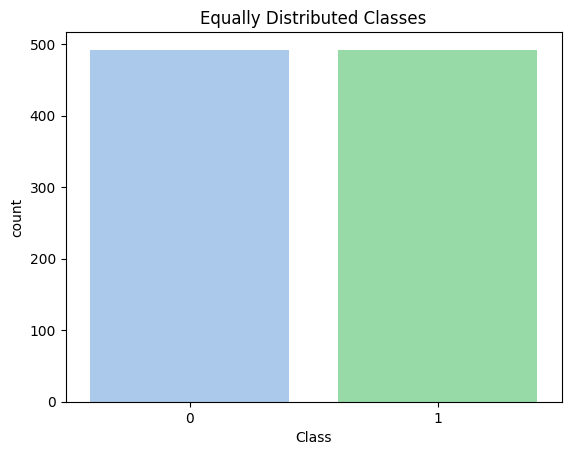

In [14]:
sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])
plt.title("Equally Distributed Classes")
plt.show()

New dataframe with 50% Fraud and 50% Non Fraud

### Second EDA

Correlation Metric to better understand our data. We want to know if there are features that influence heavily in whether a specific is a fraud.

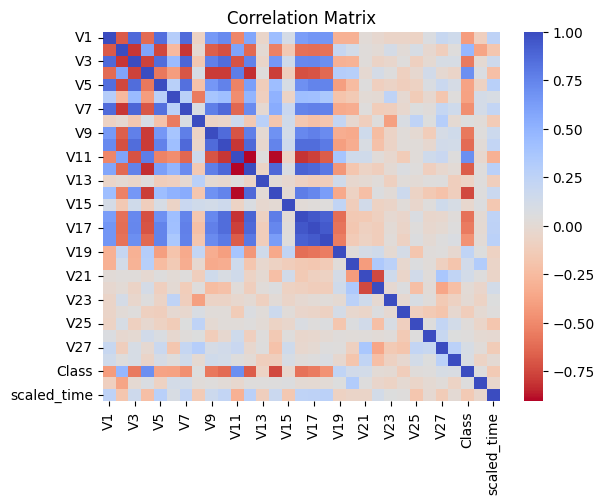

In [15]:
sns.heatmap(new_df.corr(), cmap='coolwarm_r')
plt.title("Correlation Matrix")
plt.show()

<b>Explanation</b>: 

Negative Correlations: V17, V14, V12 and V10 are negatively correlated. Meaning lower these values are, the more likely the end result will be fraud transaction.

Positive Correlations: V2, V4, V11 and V19 are positively correlated. Higher these values, more likely the ned result will be fraud transaction.

### Removing Outliers

#### Negative Correlations

Removing extreme outliers for better model accuracy

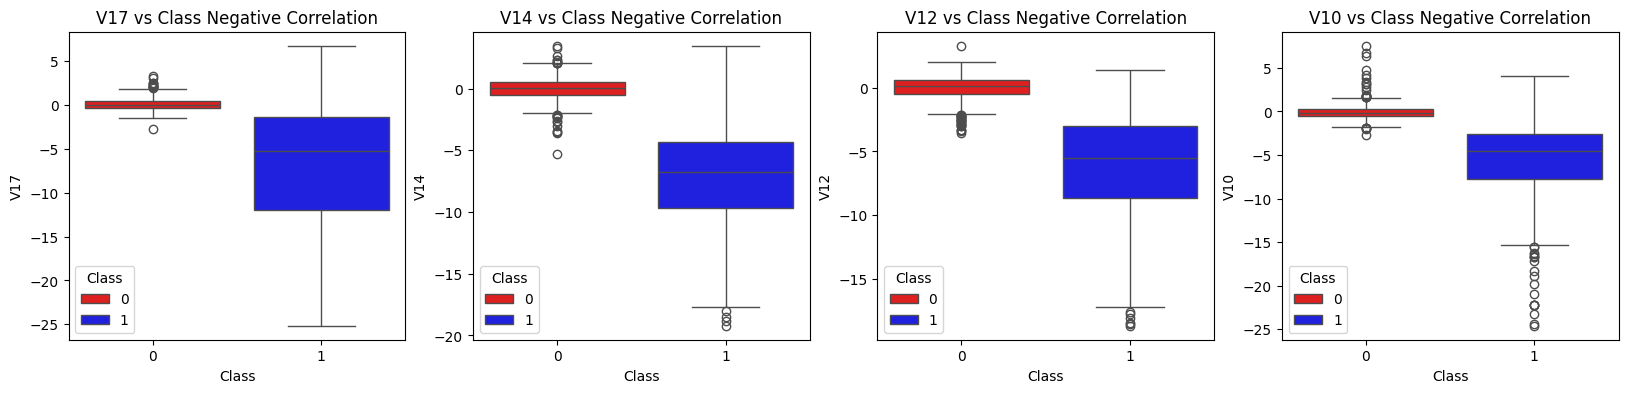

In [16]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V17", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V17 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V14", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V14 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V12", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V12 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V10 vs Class Negative Correlation")
plt.show()

#### Positive Correlation

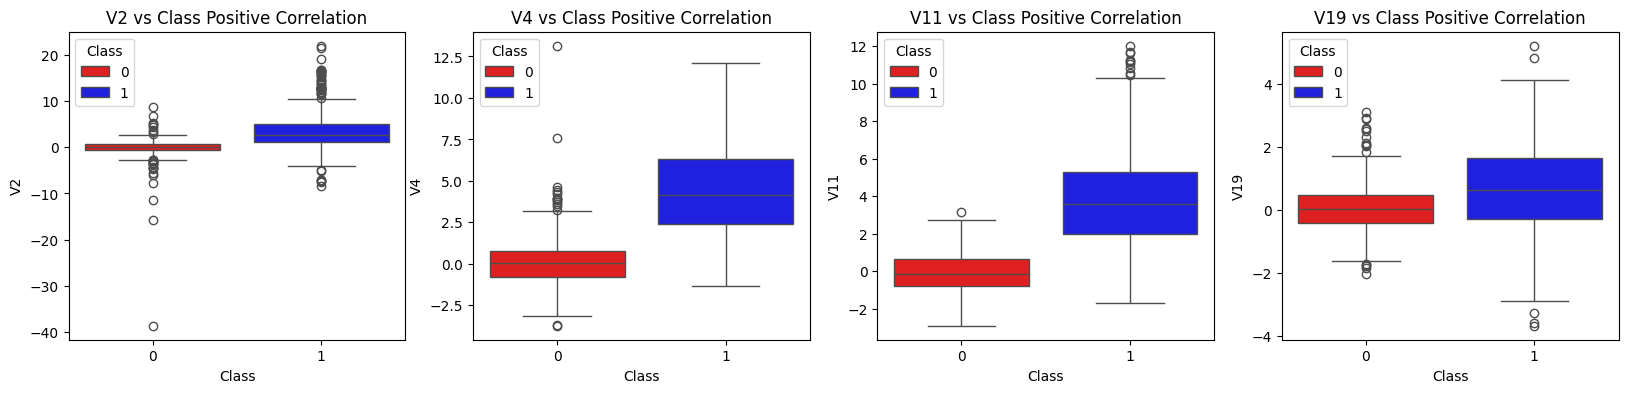

In [17]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V4", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V4 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V11", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V11 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V19", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V19 vs Class Positive Correlation")
plt.show()

#### Removing V2 and V10 Feature outlier

Removing too much outliers can lose information make a model underfit.

In [20]:
#IQR
#For V2
v2_fraud = new_df['V2'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v2_fraud, 25), np.percentile(v2_fraud, 75)
v2_iqr = q75 - q25

v2_cut_off = v2_iqr * 1.5
v2_lower, v2_upper = q25 - v2_cut_off, q75 + v2_cut_off

new_df = new_df.drop(new_df[(new_df['V2'] > v2_upper) | (new_df['V2'] < v2_lower)].index) #removing outlier


In [21]:
#For V10
v10_fraud = new_df['V10'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off

new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index) #removing outlier

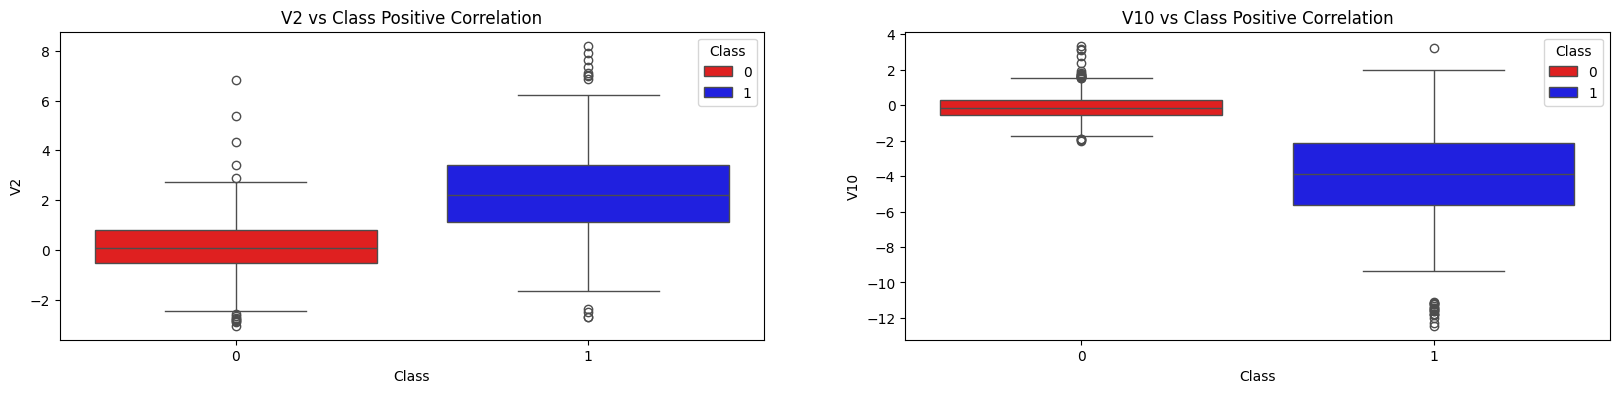

In [22]:
#Boxplot after removing IQR
f, axes = plt.subplots(ncols=2, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V10 vs Class Positive Correlation")
plt.show()


In [23]:
#Remaining rows
new_df.shape

(855, 31)

### Model Training

Continue using new_df as a main dataframe.

Train-Test Split


In [24]:
from sklearn.model_selection import train_test_split

# Features & target
X = new_df.drop('Class', axis=1)
y = new_df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (684, 30)
Test set shape: (171, 30)


Logistic Regression Model

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
# Predictions
y_pred_lr = log_reg.predict(X_test)

In [27]:
# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.9473684210526315

Confusion Matrix:
 [[93  1]
 [ 8 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95        94
           1       0.99      0.90      0.94        77

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



XGBoost Model

In [28]:
from xgboost import XGBClassifier

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [29]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

In [30]:
# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.9473684210526315

Confusion Matrix:
 [[93  1]
 [ 8 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95        94
           1       0.99      0.90      0.94        77

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



ROC Curve Comparison between two models

Logistic Regression ROC AUC: 0.9725062171870682
XGBoost ROC AUC: 0.9708483006355346


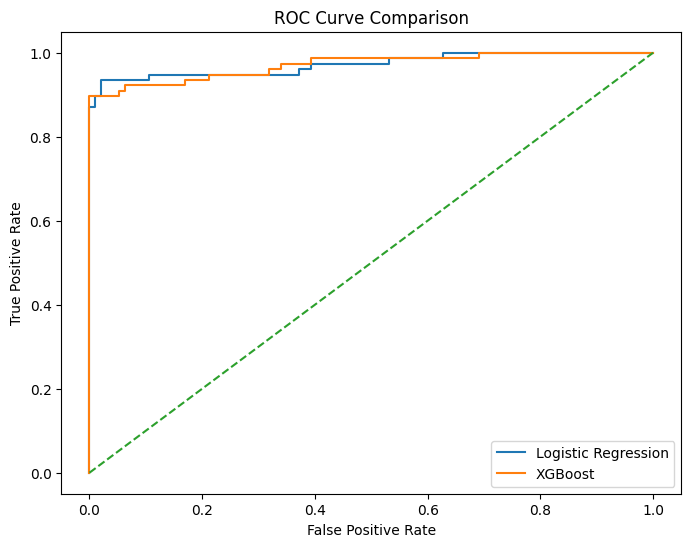

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ROC AUC scores
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Prediction on New / Test Samples

In [32]:
# Example: predicting first 5 samples from test set
sample_data = X_test.iloc[:5]

lr_predictions = log_reg.predict(sample_data)
xgb_predictions = xgb_model.predict(sample_data)

print("Logistic Regression Predictions:", lr_predictions)
print("XGBoost Predictions:", xgb_predictions)

Logistic Regression Predictions: [0 0 0 1 0]
XGBoost Predictions: [0 0 0 1 0]


### Evaluation